# Phase 6 — LightGBM

In [1]:
import sys
sys.path.insert(0, '..')
from src.data.loader import load_processed
from src.features.build_features import build_feature_set
from src.models.lightgbm_model import fit_lightgbm, predict_lightgbm, DEFAULT_FEATURES
from src.evaluation.metrics import evaluate_all

In [2]:
df = load_processed()
hourly = df.resample('h').mean().dropna()
features_df = build_feature_set(hourly)

In [3]:
train = features_df[features_df.index < '2010-01-01']
test = features_df[(features_df.index >= '2010-01-01') & (features_df.index < '2010-02-01')]

model = fit_lightgbm(train)
preds = predict_lightgbm(model, test)
evaluate_all(test['Global_active_power'].values, preds)

{'MAE': 0.4153089142296607,
 'RMSE': 0.6022639511699891,
 'MAPE': 39.545108655754134,
 'sMAPE': 31.27338523297586}

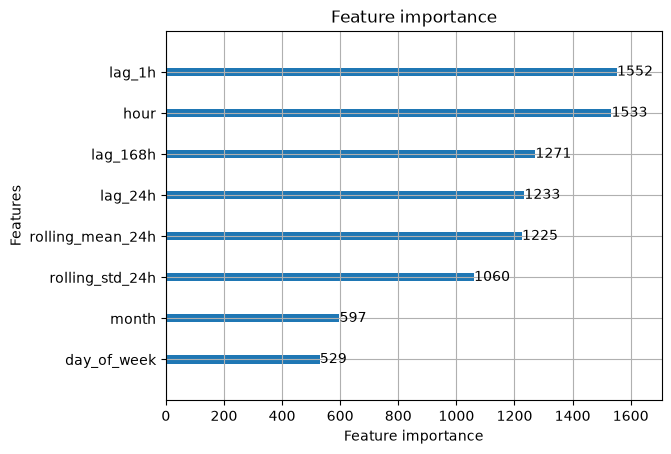

In [4]:
import matplotlib.pyplot as plt
import lightgbm as lgb
lgb.plot_importance(model)
plt.show()